In [38]:
import os

os.chdir("/workspaces/F1")

print("Working directory:", os.getcwd())


Working directory: /workspaces/F1


In [41]:
!pip install -r requirements.txt

In [40]:
!python -m experiments.monza_run

Lap time: 81.71813983197349


In [42]:
!ls results

monza_telemetry.csv


In [43]:
import pandas as pd

df = pd.read_csv("results/monza_telemetry.csv")

df.head()

,time,power,soc,distance,speed
0,0.0,0.0,0.6,7.5,55.879630
1,0.2,0.0,0.6,22.5,56.527778
2,0.4,0.0,0.6,37.5,57.175926
3,0.6,0.0,0.6,52.5,57.824074
4,0.8,0.0,0.6,67.5,58.472222


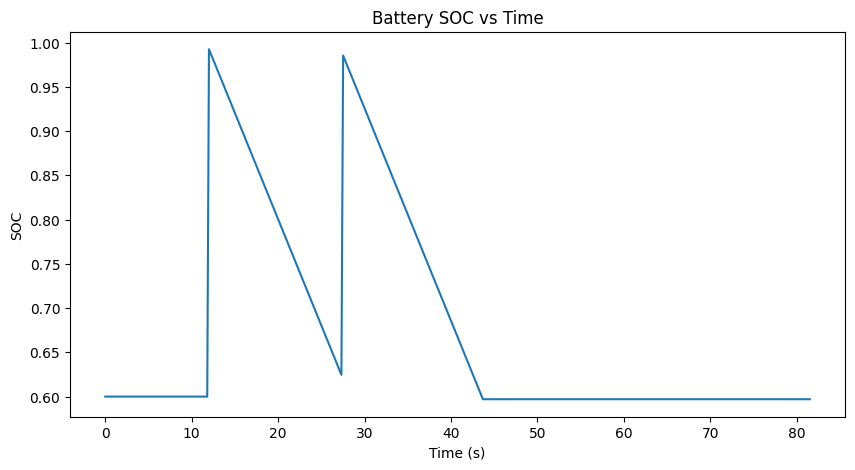

In [45]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["soc"])
plt.xlabel("Time (s)")
plt.ylabel("SOC")
plt.title("Battery SOC vs Time")
plt.show()


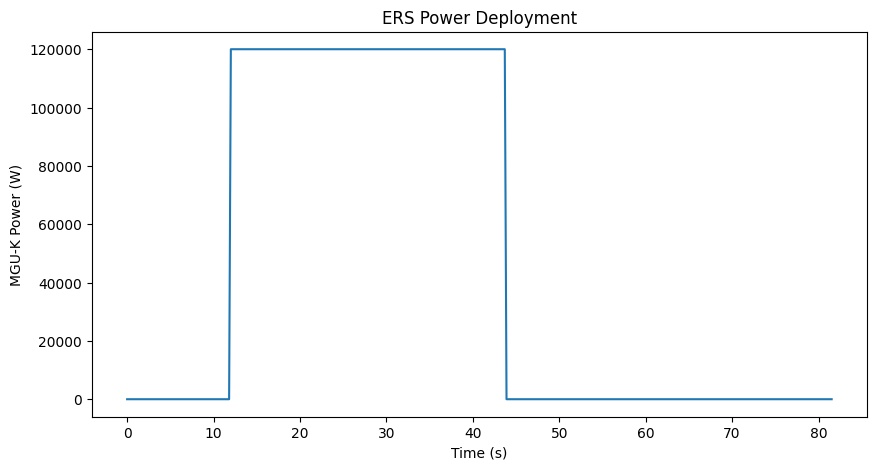

In [49]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["power"])
plt.xlabel("Time (s)")
plt.ylabel("MGU-K Power (W)")
plt.title("ERS Power Deployment")
plt.show()

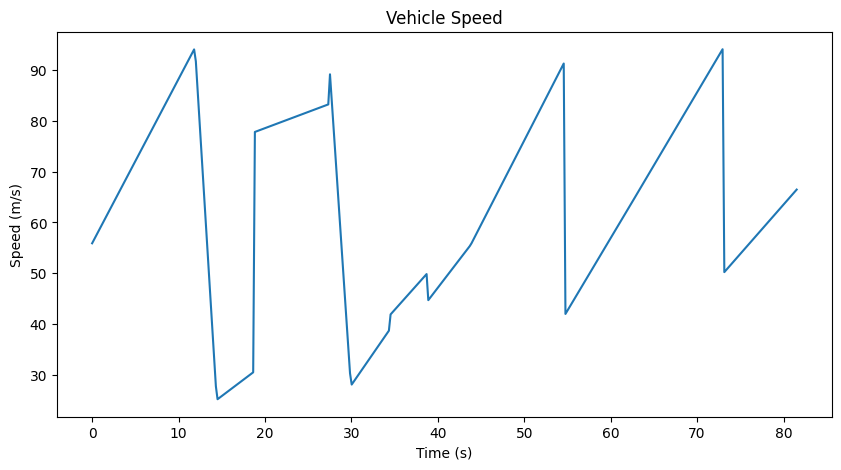

In [46]:
plt.figure(figsize=(10,5))
plt.plot(df["time"], df["speed"])
plt.xlabel("Time (s)")
plt.ylabel("Speed (m/s)")
plt.title("Vehicle Speed")
plt.show()

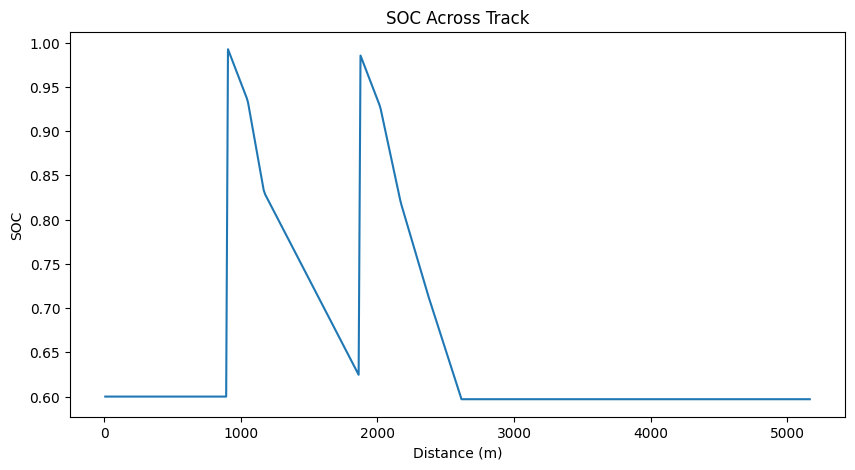

In [50]:
plt.figure(figsize=(10,5))
plt.plot(df["distance"], df["soc"])
plt.xlabel("Distance (m)")
plt.ylabel("SOC")
plt.title("SOC Across Track")
plt.show()

In [51]:
print("Telemetry summary")

print("Min SOC:", df["soc"].min())
print("Max SOC:", df["soc"].max())

print("Max power deployed:", df["power"].max())
print("Average power:", df["power"].mean())

Telemetry summary
Min SOC: 0.5970161969332435
Max SOC: 0.9925159262572052
Max power deployed: 120000.0
Average power: 47070.217917675545


In [ ]:
# Load strategy results
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.read_csv("results/strategy_results.csv")
strategies = ["conservative", "aggressive", "lookahead"]
socs = [0.4, 0.6, 0.8]
colors = {"conservative": "blue", "aggressive": "red", "lookahead": "green"}

In [ ]:
# 1. Lap time comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.lap_time, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Lap Time (s)")
ax.set_title("Lap Time vs Initial SOC by Strategy")
ax.legend(); plt.show()

In [ ]:
# 2. Energy deployed comparison
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.energy_deployed_j / 1e6, marker="o", label=s, color=colors[s])
ax.set_xlabel("Initial SOC"); ax.set_ylabel("Energy Deployed (MJ)")
ax.set_title("Energy Deployed vs Initial SOC"); ax.legend(); plt.show()

In [ ]:
# 3. SOC delta (end - start)
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    d = summary[summary.strategy == s]
    ax.plot(d.initial_soc, d.soc_end - d.initial_soc, marker="o", label=s, color=colors[s])
ax.axhline(0, linestyle="--", color="gray")
ax.set_xlabel("Initial SOC"); ax.set_ylabel("ΔSOC")
ax.set_title("SOC Change per Lap"); ax.legend(); plt.show()

In [ ]:
# 4. Per-strategy telemetry overlay (SOC=0.6)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    axes[0].plot(tel.distance, tel.soc, label=s, color=colors[s])
    axes[1].plot(tel.distance, tel.power / 1000, label=s, color=colors[s])
    axes[2].plot(tel.distance, tel.speed * 3.6, label=s, color=colors[s])
for ax, ylabel in zip(axes, ["SOC", "Power (kW)", "Speed (km/h)"]):
    ax.set_ylabel(ylabel); ax.legend()
axes[2].set_xlabel("Distance (m)")
fig.suptitle("Strategy Comparison at SOC=0.6"); plt.tight_layout(); plt.show()

In [ ]:
# 5. Segment-level mean power heatmap
import numpy as np
seg_data = {}
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    seg_data[s] = tel.groupby("segment_name")["power"].mean() / 1000

seg_df = pd.DataFrame(seg_data)
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(seg_df.values, aspect="auto", cmap="RdYlGn")
ax.set_xticks(range(len(strategies))); ax.set_xticklabels(strategies)
ax.set_yticks(range(len(seg_df))); ax.set_yticklabels(seg_df.index)
plt.colorbar(im, ax=ax, label="Mean Power (kW)")
ax.set_title("Mean Deployment Power by Segment & Strategy"); plt.tight_layout(); plt.show()

In [ ]:
# 6. Cumulative energy deployed
fig, ax = plt.subplots(figsize=(10, 5))
for s in strategies:
    tel = pd.read_csv(f"results/telemetry_{s}_soc6.csv")
    ax.plot(tel.distance, tel.cumulative_energy_deployed_j / 1e6, label=s, color=colors[s])
ax.set_xlabel("Distance (m)"); ax.set_ylabel("Cumulative Energy Deployed (MJ)")
ax.set_title("Cumulative Deployment vs Track Position"); ax.legend(); plt.show()

In [4]:
cd ..

/workspaces/F1


In [6]:

!pytest tests/ -v


============================= test session starts ==============================
platform linux -- Python 3.12.1, pytest-9.0.2, pluggy-1.6.0 -- /usr/local/python/3.12.1/bin/python3
cachedir: .pytest_cache
rootdir: /workspaces/F1
plugins: anyio-4.11.0
collected 0 items / 1 error                                                    

==================================== ERRORS ====================================
________________ ERROR collecting tests/test_energy_balance.py _________________
ImportError while importing test module '/workspaces/F1/tests/test_energy_balance.py'.
Hint: make sure your test modules/packages have valid Python names.
Traceback:
/usr/local/python/3.12.1/lib/python3.12/importlib/__init__.py:90: in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tests/test_energy_balance.py:2: in <module>
    from sim.battery import Battery
E   ModuleNotFoundError: No module named 'sim'
==